In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
nav = pd.read_csv(
    "data/processed/02_nav_history_cleaned.csv"
)

benchmark = pd.read_csv(
    "data/processed/10_benchmark_indices_cleaned.csv"
)

performance = pd.read_csv(
    "data/processed/07_scheme_performance_cleaned.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

print(nav.shape)
print(benchmark.shape)
print(performance.shape)

(46000, 3)
(8050, 3)
(40, 19)


In [3]:
print("NAV Columns:")
print(nav.columns)

print("\nBenchmark Columns:")
print(benchmark.columns)

print("\nPerformance Columns:")
print(performance.columns)

NAV Columns:
Index(['amfi_code', 'date', 'nav'], dtype='object')

Benchmark Columns:
Index(['date', 'index_name', 'close_value'], dtype='object')

Performance Columns:
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


In [4]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby(
    "amfi_code"
)["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


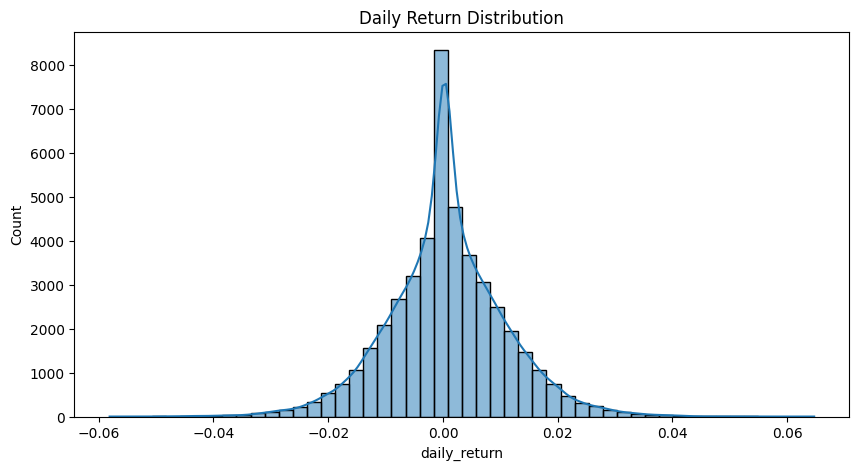

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")

plt.savefig(
    "charts/daily_return_distribution.png"
)

plt.show()

In [6]:
cagr_table = performance[
    [
        "amfi_code",
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
]

cagr_table.head()

,amfi_code,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,119552,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,119598,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,119599,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [7]:
cagr_table.to_csv(
    "reports/cagr_comparison.csv",
    index=False
)

In [8]:
sharpe_rank = performance[
    [
        "amfi_code",
        "scheme_name",
        "sharpe_ratio"
    ]
].sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_rank.head(10)

,amfi_code,scheme_name,sharpe_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,120844,Kotak Liquid Fund - Regular - Growth,6.18
30,101208,ABSL Liquid Fund - Regular - Growth,5.14
9,100025,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,118636,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,118632,Nippon India Large Cap Fund - Regular - Growth,1.00


In [9]:
sortino_rank = performance[
    [
        "amfi_code",
        "scheme_name",
        "sortino_ratio"
    ]
].sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_rank.head(10)

,amfi_code,scheme_name,sortino_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,10.37
23,120844,Kotak Liquid Fund - Regular - Growth,9.70
30,101208,ABSL Liquid Fund - Regular - Growth,8.76
9,100025,HDFC Short Term Debt Fund - Regular - Growth,2.79
19,118636,Nippon India Gilt Securities Fund - Regular - ...,2.38
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.70
15,118632,Nippon India Large Cap Fund - Regular - Growth,1.68
3,119599,SBI Small Cap Fund - Direct Plan - Growth,1.67
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.66


In [10]:
alpha_beta = performance[
    [
        "amfi_code",
        "scheme_name",
        "alpha",
        "beta"
    ]
]

alpha_beta.head()

,amfi_code,scheme_name,alpha,beta
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,119552,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,119599,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [11]:
alpha_beta.to_csv(
    "reports/alpha_beta.csv",
    index=False
)

In [12]:
drawdown_rank = performance[
    [
        "amfi_code",
        "scheme_name",
        "max_drawdown_pct"
    ]
].sort_values(
    "max_drawdown_pct"
)

drawdown_rank.head(10)

,amfi_code,scheme_name,max_drawdown_pct
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,-33.50
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,-33.15
26,119094,Axis Midcap Fund - Regular - Growth,-32.38
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,-32.22
17,118634,Nippon India Small Cap Fund - Regular - Growth,-30.87
24,119092,Axis Bluechip Fund - Regular - Growth,-27.54
38,149323,DSP Midcap Fund - Regular - Growth,-26.99
18,118635,Nippon India ETF Nifty 50 BeES,-26.75
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,-26.59
10,120503,ICICI Pru Bluechip Fund - Regular - Growth,-25.91


In [13]:
scorecard = performance.copy()

scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    (-scorecard["expense_ratio_pct"])
    .rank(pct=True)
)

scorecard["drawdown_rank"] = (
    (-scorecard["max_drawdown_pct"])
    .rank(pct=True)
)

scorecard["fund_score"] = (
      30 * scorecard["return_rank"]
    + 25 * scorecard["sharpe_rank"]
    + 20 * scorecard["alpha_rank"]
    + 15 * scorecard["expense_rank"]
    + 10 * scorecard["drawdown_rank"]
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard[
    [
        "scheme_name",
        "fund_score"
    ]
].head(10)

,scheme_name,fund_score
3,SBI Small Cap Fund - Direct Plan - Growth,72.7500
22,Kotak Flexicap Fund - Regular - Growth,71.5000
21,Kotak Emerging Equity Fund - Regular - Growth,70.5000
29,ABSL Small Cap Fund - Regular - Growth,68.2500
2,SBI Small Cap Fund - Regular Plan - Growth,64.3750
34,Mirae Asset Large Cap Fund - Regular - Growth,63.9375
9,HDFC Short Term Debt Fund - Regular - Growth,63.0000
14,ICICI Pru Liquid Fund - Regular - Growth,61.7500
12,ICICI Pru Midcap Fund - Regular - Growth,61.0000
11,ICICI Pru Bluechip Fund - Direct - Growth,59.6250


In [14]:
scorecard.to_csv(
    "reports/fund_scorecard.csv",
    index=False
)

In [15]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [16]:
top5 = scorecard.head(5)

top5[["scheme_name", "fund_score"]]

,scheme_name,fund_score
3,SBI Small Cap Fund - Direct Plan - Growth,72.750
22,Kotak Flexicap Fund - Regular - Growth,71.500
21,Kotak Emerging Equity Fund - Regular - Growth,70.500
29,ABSL Small Cap Fund - Regular - Growth,68.250
2,SBI Small Cap Fund - Regular Plan - Growth,64.375


In [17]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50["date"] = pd.to_datetime(
    nifty50["date"]
)

nifty50.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [18]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


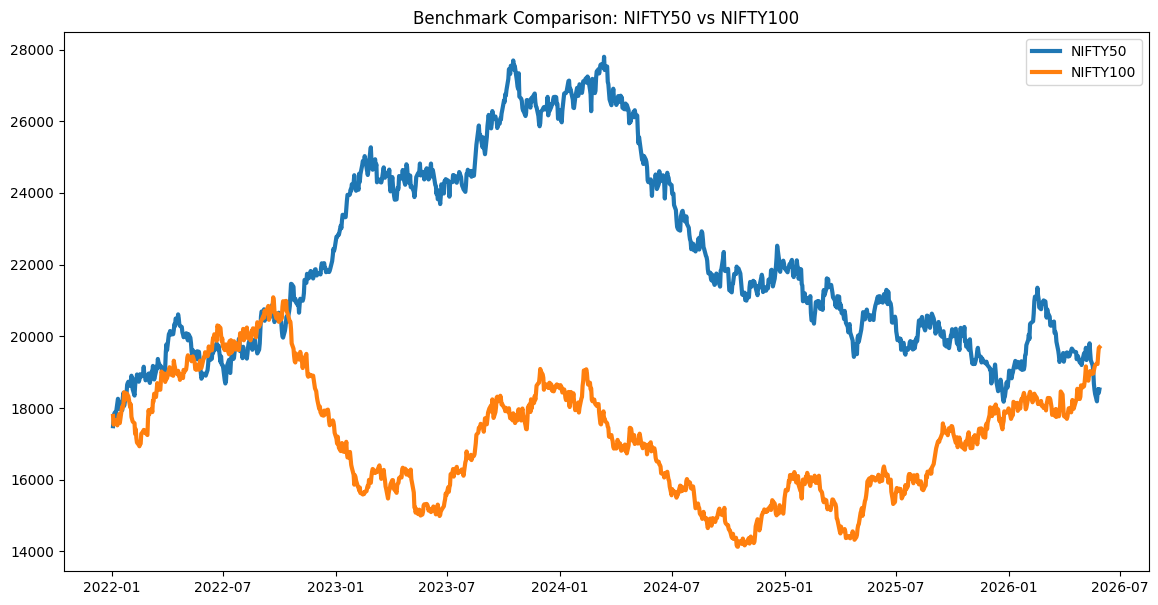

In [19]:
plt.figure(figsize=(14,7))

plt.plot(
    nifty50["date"],
    nifty50["close_value"],
    label="NIFTY50",
    linewidth=3
)

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    label="NIFTY100",
    linewidth=3
)

plt.title(
    "Benchmark Comparison: NIFTY50 vs NIFTY100"
)

plt.legend()

plt.savefig(
    "charts/benchmark_comparison.png"
)

plt.show()

In [20]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

tracking_error_results = []

for code in top5["amfi_code"]:

    fund = nav[
        nav["amfi_code"] == code
    ].copy()

    fund["fund_return"] = (
        fund["nav"]
        .pct_change()
    )

    merged = pd.merge(
        fund,
        nifty100[
            ["date",
             "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    te = (
        (
            merged["fund_return"]
            -
            merged["benchmark_return"]
        )
        .std()
    ) * np.sqrt(252)

    tracking_error_results.append(
        [code, te]
    )

tracking_error = pd.DataFrame(
    tracking_error_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error

,amfi_code,tracking_error
0,119599,0.277135
1,120843,0.206425
2,120842,0.219169
3,101207,0.292117
4,119598,0.283881


In [21]:
tracking_error.to_csv(
    "reports/tracking_error.csv",
    index=False
)